# DAMICORE abuse categories

This minimal experiment represents each abuse category as one document made from aggregated context counts. All female-victim reports from January through June 2026 contribute to those counts; no report sample or individual identifier is exported.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import psycopg
from damicore import estimate, run
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")

DATABASE_URL = os.getenv("DISQUE100_DATABASE_URL", "postgresql:///disque100")
START_DATE = "2026-01-01"
END_DATE = "2026-07-01"
VICTIM_GENDER = "FEMININO"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "damicore_abuse_categories_2026_h1"
WORK_DIR = ARTIFACT_DIR / "work"
CORPUS_DIR = WORK_DIR / "corpus"
RUN_DIR = WORK_DIR / "run"
RESULTS_DIR = ARTIFACT_DIR / "results"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Coverage and aggregated contexts

`source_hash` is used only inside PostgreSQL to count distinct reports. The notebook receives coverage totals and aggregate counts, never individual reports.


In [2]:
category_sql = '''
nullif(concat_ws(' > ',
    nullif(trim(split_part(violation, '>', 1)), ''),
    nullif(trim(split_part(violation, '>', 2)), '')
), '')
'''

coverage_query = f'''
WITH reports AS (
    SELECT source_hash,
           bool_or(violation IS NOT NULL) AS has_violation,
           bool_or(({category_sql}) IS NOT NULL) AS has_category
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
    GROUP BY source_hash
)
SELECT count(*) AS female_reports,
       count(*) FILTER (WHERE has_category) AS reports_with_category,
       count(*) FILTER (WHERE NOT has_violation) AS reports_without_violation
FROM reports
'''

context_query = f'''
WITH report_values AS (
    SELECT DISTINCT
        source_hash,
        {category_sql} AS category,
        victim_age_group AS age_group,
        victim_suspect_relationship AS relationship,
        violation_setting AS setting,
        to_char(date_trunc('month', registered_at), 'YYYY-MM') AS month
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
), contexts AS (
    SELECT category, source_hash, 'report'::text AS dimension, 'ALL'::text AS value
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'age_group', age_group
    FROM report_values WHERE category IS NOT NULL AND age_group IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'relationship', relationship
    FROM report_values WHERE category IS NOT NULL AND relationship IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'setting', setting
    FROM report_values WHERE category IS NOT NULL AND setting IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'month', month
    FROM report_values WHERE category IS NOT NULL
)
SELECT category, dimension, value, count(DISTINCT source_hash) AS report_count
FROM contexts
GROUP BY category, dimension, value
ORDER BY category, dimension, value
'''

parameters = (START_DATE, END_DATE, VICTIM_GENDER)
with psycopg.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute(coverage_query, parameters)
        coverage = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])
        cursor.execute(context_query, parameters)
        context_counts = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])

display(coverage.rename(columns={
    "female_reports": "Female-victim reports",
    "reports_with_category": "Reports with category",
    "reports_without_violation": "Reports without violation",
}))
print(f"Abuse categories available to DAMICORE: {context_counts['category'].nunique()}")


,Female-victim reports,Reports with category,Reports without violation
0,189909,189909,0


Abuse categories available to DAMICORE: 48


## 2. One deterministic document per abuse category

Each file contains only context values and distinct-report counts. The category name stays in a separate mapping so it does not influence compression similarity.


In [3]:
for old_file in CORPUS_DIR.glob("*.txt"):
    old_file.unlink()

category_rows = []
for number, category in enumerate(sorted(context_counts["category"].unique()), start=1):
    label = f"category-{number:03d}.txt"
    rows = context_counts.loc[context_counts["category"] == category]
    lines = [
        f"{row.dimension}|{row.value}|{int(row.report_count)}"
        for row in rows.itertuples(index=False)
    ]
    (CORPUS_DIR / label).write_text("\n".join(lines) + "\n", encoding="utf-8")
    support = int(rows.loc[rows["dimension"] == "report", "report_count"].iloc[0])
    category_rows.append({"label": label, "category": category, "report_count": support})

category_map = pd.DataFrame(category_rows)
category_map.to_csv(WORK_DIR / "category-map.csv", index=False)
display(category_map)


,label,category,report_count
0,category-001.txt,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,626
1,category-002.txt,DIREITOS CIVIS E POLÍTICOS > CULTURAL,17
2,category-003.txt,DIREITOS CIVIS E POLÍTICOS > LIVRE EXERCÍCIO D...,751
3,category-004.txt,DIREITOS CIVIS E POLÍTICOS > MEMÓRIA E VERDADE,257
4,category-005.txt,DIREITOS CIVIS E POLÍTICOS > NACIONALIDADE,8
5,category-006.txt,DIREITOS CIVIS E POLÍTICOS > PARTICIPAÇÃO/DEMO...,15
6,category-007.txt,DIREITOS CIVIS E POLÍTICOS > PROPRIEDADE,1273
7,category-008.txt,DIREITOS CIVIS E POLÍTICOS > RETENÇÃO DE DOCUM...,627
8,category-009.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,56
9,category-010.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,18


## 3. Minimal DAMICORE flow

The sequence is `estimate → run → membership → distance matrix → tree`. Lower NCD values mean more similar context distributions.


In [4]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())
if not preview.within_limits:
    raise RuntimeError(f"DAMICORE limits exceeded: {preview.violations}")

result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)
try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    tree_newick = result.tree_newick
finally:
    result.close()

category_clusters = (
    membership[["label", "cluster"]]
    .merge(category_map, on="label", validate="one_to_one")
    .sort_values(["cluster", "category"])
)
category_clusters[["category", "cluster", "report_count"]].to_csv(
    RESULTS_DIR / "category-clusters.csv", index=False
)

display(category_clusters[["category", "cluster", "report_count"]])
display(distance_matrix.round(3))
print("DAMICORE tree (Newick):")
print(tree_newick)


{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-001.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-002.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-003.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-004.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-005.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-006.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/corpus/category-007.txt'),
  PosixPath('/Users/erickpatrickbar

distance: 100%|██████████| 1128/1128 [00:00<00:00, 2804.76pair/s]


,category,cluster,report_count
0,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,0,626
6,DIREITOS CIVIS E POLÍTICOS > PROPRIEDADE,0,1273
13,DIREITOS SOCIAIS > EDUCAÇÃO,0,2847
14,DIREITOS SOCIAIS > LAZER,0,1372
15,DIREITOS SOCIAIS > MORADIA,0,2239
24,IGUALDADE > INJÚRIA RACIAL E ÉTNICA,0,787
25,IGUALDADE > RACISMO,0,1222
1,DIREITOS CIVIS E POLÍTICOS > CULTURAL,1,17
4,DIREITOS CIVIS E POLÍTICOS > NACIONALIDADE,1,8
5,DIREITOS CIVIS E POLÍTICOS > PARTICIPAÇÃO/DEMO...,1,15


,category-001.txt,category-002.txt,category-003.txt,category-004.txt,category-005.txt,category-006.txt,category-007.txt,category-008.txt,category-009.txt,category-010.txt,...,category-039.txt,category-040.txt,category-041.txt,category-042.txt,category-043.txt,category-044.txt,category-045.txt,category-046.txt,category-047.txt,category-048.txt
category-001.txt,0.000,0.858,0.471,0.594,0.778,0.828,0.476,0.452,0.607,0.709,...,0.730,0.778,0.712,0.636,0.771,0.554,0.562,0.593,0.505,0.505
category-002.txt,0.858,0.000,0.849,0.809,0.610,0.517,0.849,0.827,0.772,0.671,...,0.656,0.604,0.691,0.796,0.672,0.820,0.783,0.817,0.871,0.823
category-003.txt,0.471,0.849,0.000,0.597,0.754,0.809,0.515,0.476,0.583,0.700,...,0.701,0.752,0.697,0.626,0.751,0.542,0.515,0.566,0.567,0.485
category-004.txt,0.594,0.809,0.597,0.000,0.743,0.782,0.654,0.617,0.598,0.745,...,0.670,0.707,0.674,0.560,0.701,0.543,0.580,0.596,0.690,0.612
category-005.txt,0.778,0.610,0.754,0.743,0.000,0.526,0.806,0.754,0.677,0.582,...,0.505,0.482,0.531,0.694,0.672,0.715,0.745,0.728,0.817,0.765
category-006.txt,0.828,0.517,0.809,0.782,0.526,0.000,0.848,0.820,0.720,0.647,...,0.640,0.524,0.676,0.776,0.694,0.789,0.785,0.780,0.866,0.819
category-007.txt,0.476,0.849,0.515,0.654,0.806,0.848,0.000,0.503,0.640,0.705,...,0.744,0.788,0.750,0.651,0.777,0.594,0.565,0.621,0.490,0.548
category-008.txt,0.452,0.827,0.476,0.617,0.754,0.820,0.503,0.000,0.598,0.706,...,0.717,0.764,0.708,0.631,0.763,0.519,0.527,0.589,0.521,0.466
category-009.txt,0.607,0.772,0.583,0.598,0.677,0.720,0.640,0.598,0.000,0.531,...,0.574,0.637,0.586,0.507,0.648,0.542,0.482,0.484,0.682,0.551
category-010.txt,0.709,0.671,0.700,0.745,0.582,0.647,0.705,0.706,0.531,0.000,...,0.479,0.560,0.546,0.597,0.621,0.705,0.634,0.587,0.746,0.695


DAMICORE tree (Newick):
(('file_000003':0.23434633732272947,'file_000017':0.24335435643346476)'nj_000045':0.002485009880484685,((('file_000033':0.2535070207840755,(('file_000011':0.49993822575756375,(('file_000010':0.24230025972292668,('file_000039':0.22797180060747826,(('file_000036':0.26429907278492515,('file_000006':0.2534362995287599,('file_000002':0.26282609654300715,('file_000037':0.1313169122818005,'file_000038':0.12235955830643477)'nj_000001':0.10561959634088802)'nj_000002':0.007782443586463683)'nj_000003':0.03577877033427135)'nj_000004':0.01485839661546473,('file_000005':0.24498997911264944,'file_000040':0.23690417130517785)'nj_000005':0.008025728858128717)'nj_000006':0.02535309574249997)'nj_000007':0.034743363855454734)'nj_000008':0.02222711325322379,('file_000041':0.26563837196049717,'file_000043':0.3079223956301212)'nj_000009':0.018294722222026945)'nj_000010':0.019924069140351608)'nj_000011':0.09707012857445552,(('file_000045':0.22840207490197653,(('file_000023':0.245071182

## 4. Graph 1 — DAMICORE cluster to abuse category

Every edge comes directly from DAMICORE membership. Larger category nodes and thicker edges indicate more distinct reports.


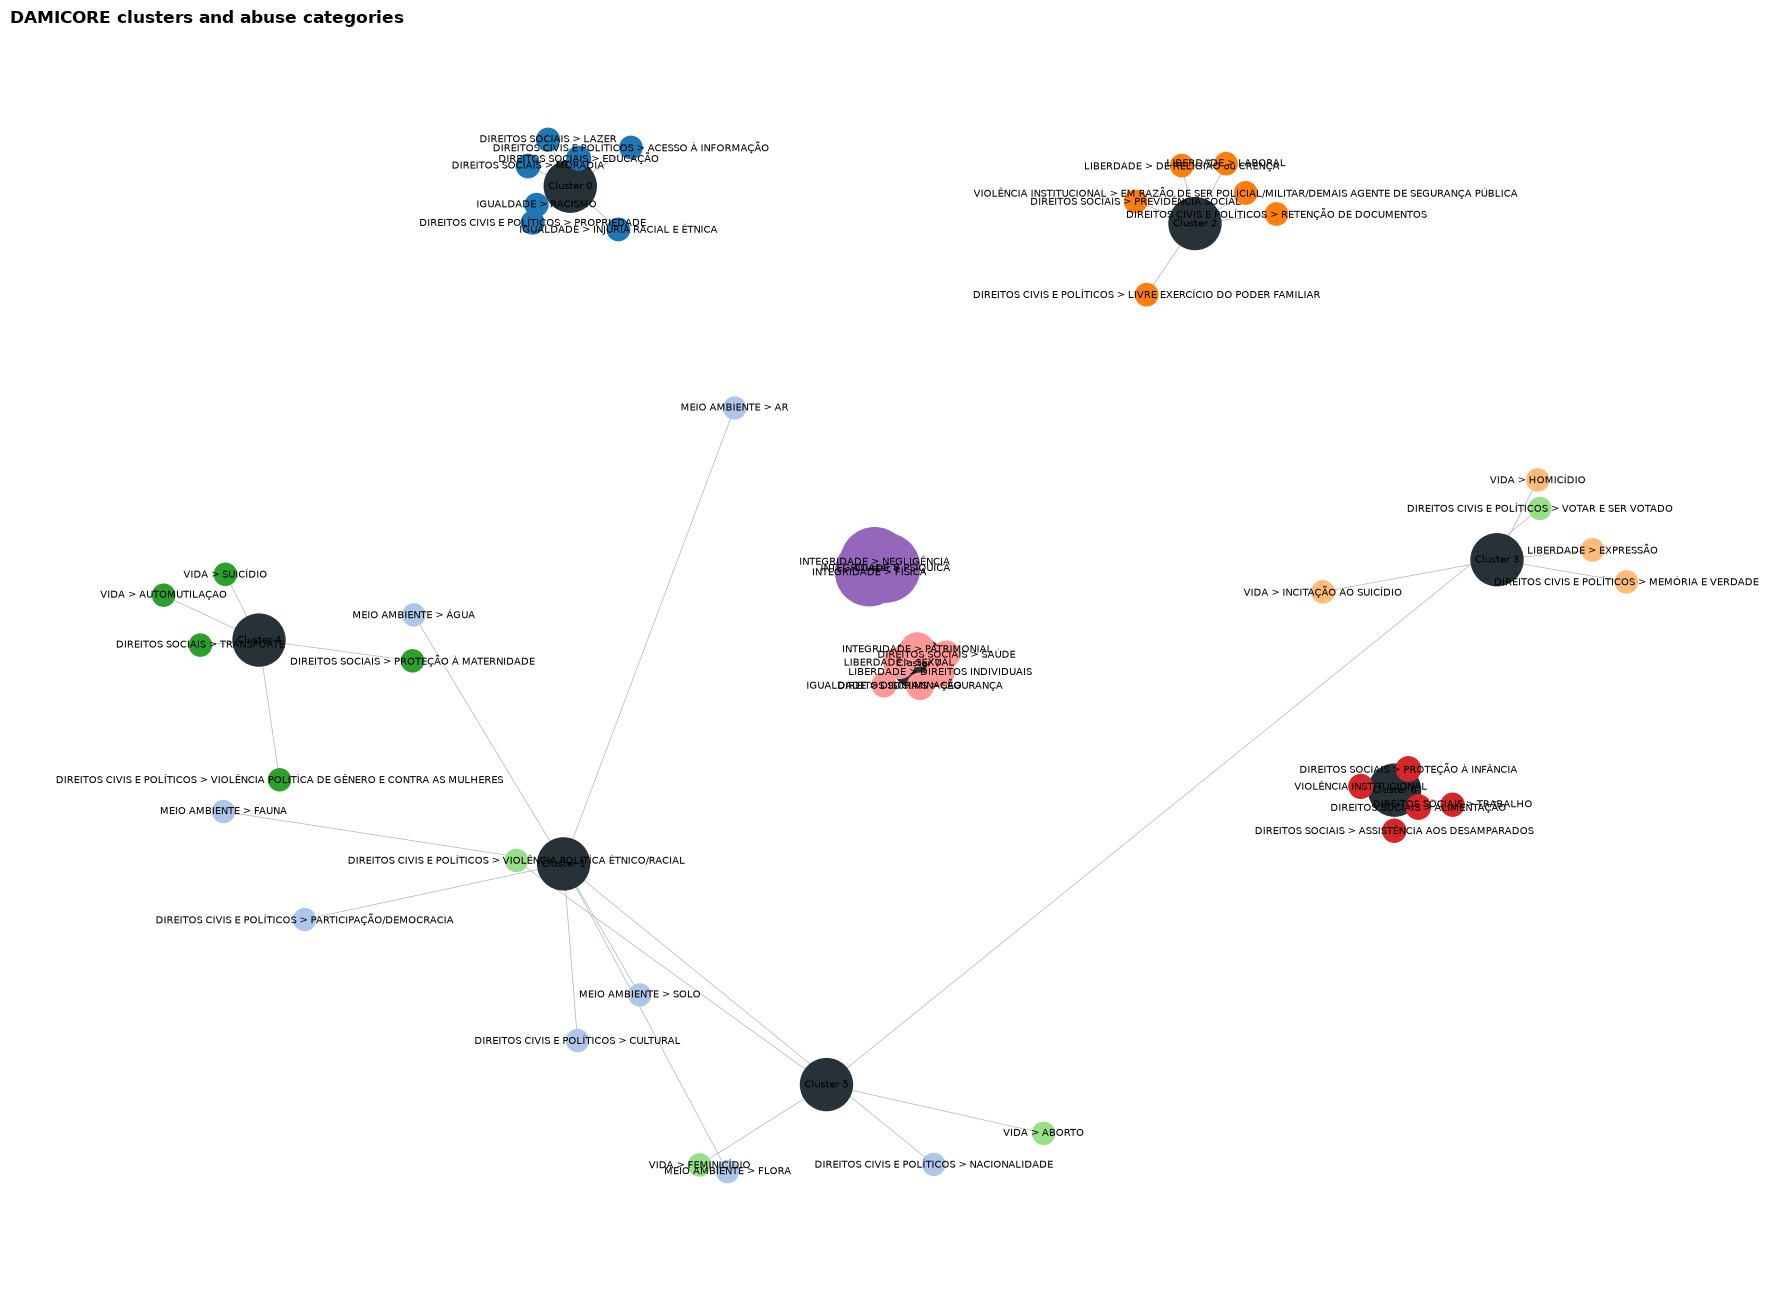

In [5]:
cluster_graph = nx.Graph(experiment="DAMICORE abuse categories 2026 H1")
for row in category_clusters.itertuples(index=False):
    cluster_node = f"cluster:{row.cluster}"
    category_node = f"category:{row.label}"
    cluster_graph.add_node(cluster_node, node_type="cluster", label=f"Cluster {row.cluster}")
    cluster_graph.add_node(
        category_node, node_type="category", label=row.category,
        cluster=int(row.cluster), report_count=int(row.report_count),
    )
    cluster_graph.add_edge(cluster_node, category_node, report_count=int(row.report_count))

for cluster in category_clusters["cluster"].unique():
    node = f"cluster:{cluster}"
    cluster_graph.nodes[node]["report_count"] = int(
        category_clusters.loc[category_clusters["cluster"] == cluster, "report_count"].sum()
    )

nx.write_graphml(cluster_graph, RESULTS_DIR / "category-clusters.graphml")

clusters = sorted(category_clusters["cluster"].unique())
cluster_colors = {cluster: plt.colormaps["tab20"](index % 20) for index, cluster in enumerate(clusters)}
max_support = category_clusters["report_count"].max()
positions = nx.spring_layout(cluster_graph, seed=42, weight="report_count", k=1.4)
node_sizes = [
    1400 if data["node_type"] == "cluster"
    else 250 + 2200 * data["report_count"] / max_support
    for _, data in cluster_graph.nodes(data=True)
]
node_colors = [
    "#263238" if data["node_type"] == "cluster" else cluster_colors[data["cluster"]]
    for _, data in cluster_graph.nodes(data=True)
]
edge_widths = [0.5 + 5 * data["report_count"] / max_support for _, _, data in cluster_graph.edges(data=True)]
labels = {node: data["label"] for node, data in cluster_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx(
    cluster_graph, positions, labels=labels, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    width=edge_widths, edge_color="#AAB5B8", font_size=7,
)
axis.set_title("DAMICORE clusters and abuse categories", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-clusters.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 5. Graph 2 — two nearest categories by NCD

Each category points to its two smallest non-self distances. Edge thickness represents `1 / (1 + NCD)`, so thicker edges mean greater similarity.


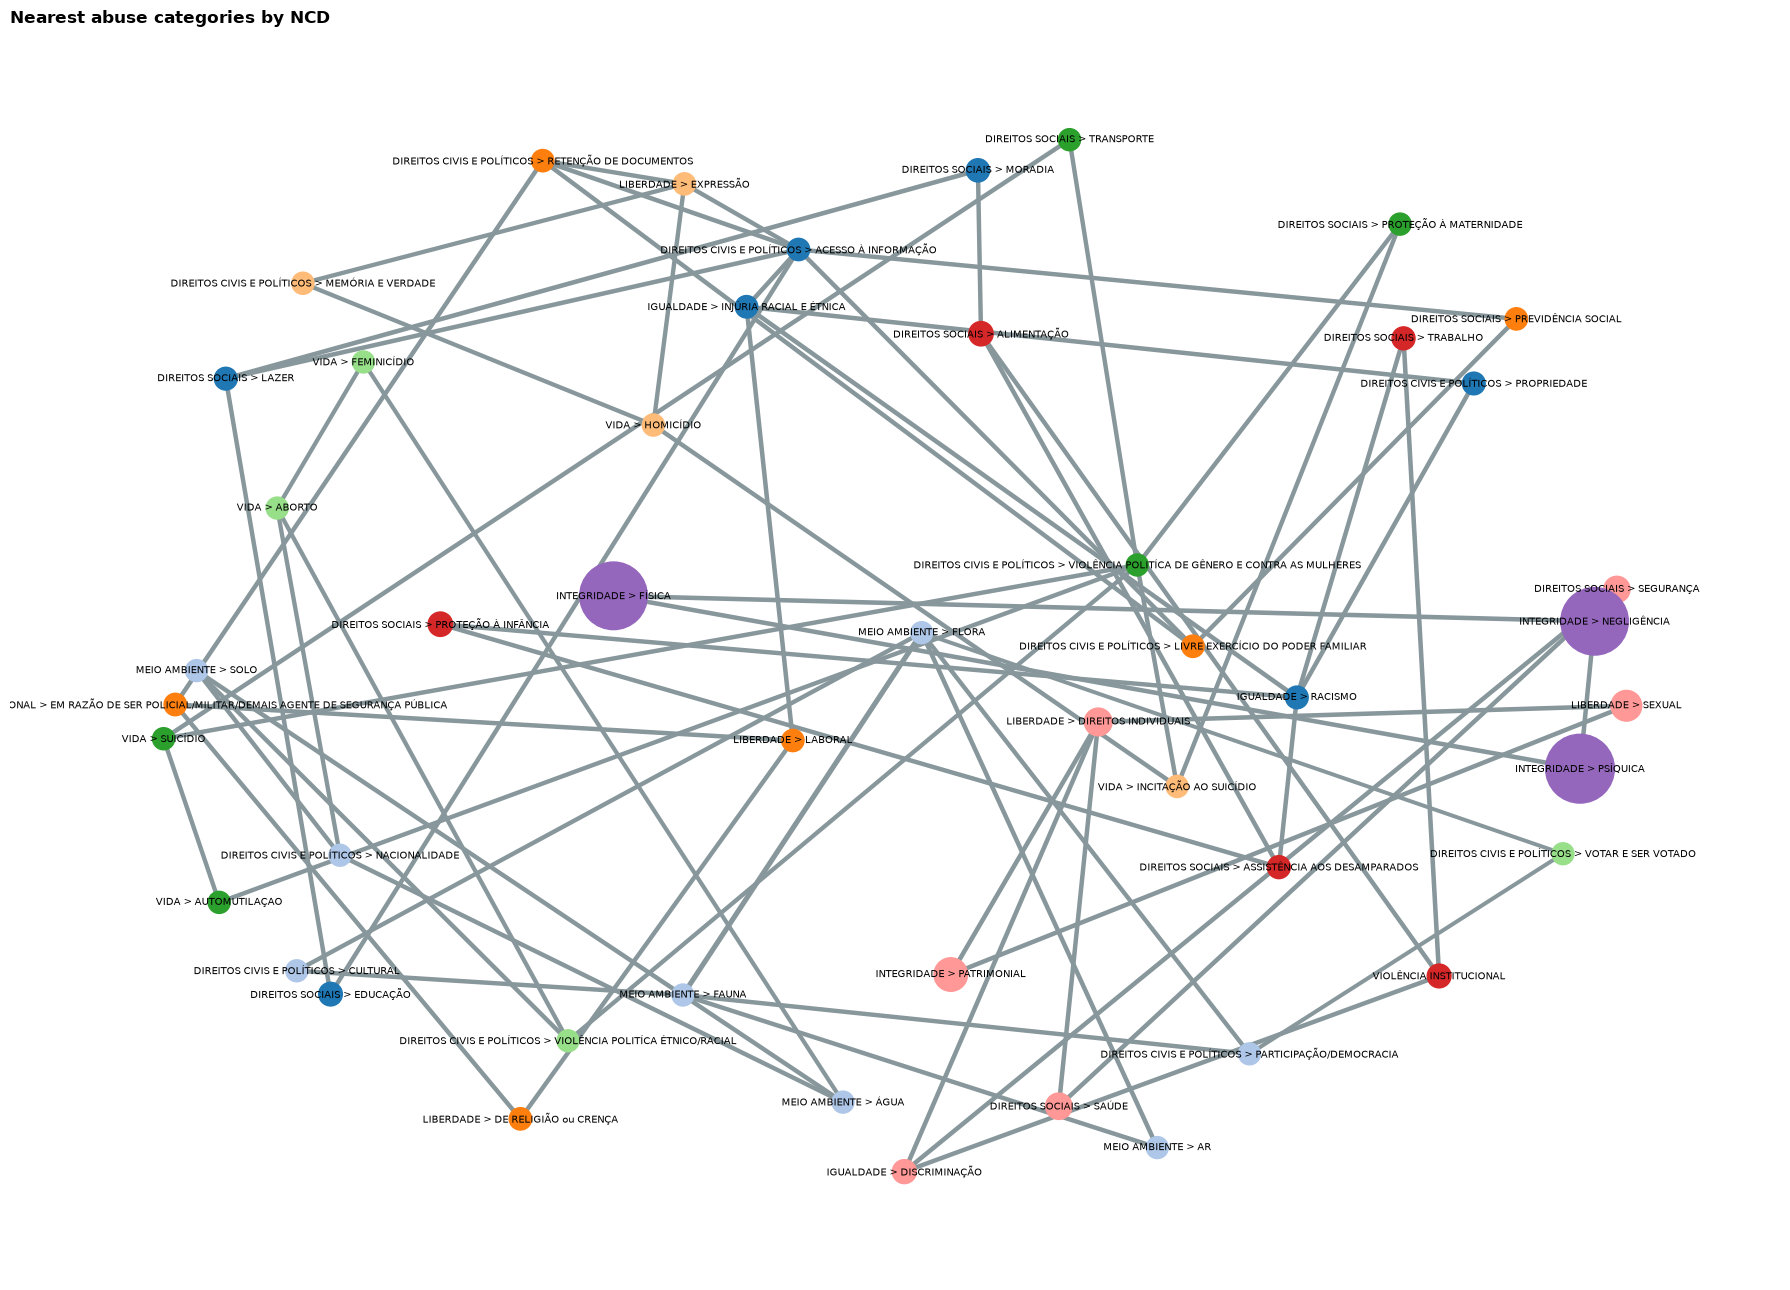

In [6]:
similarity_graph = nx.Graph(experiment="DAMICORE category similarity 2026 H1")
cluster_by_label = category_clusters.set_index("label")

for label, row in cluster_by_label.iterrows():
    similarity_graph.add_node(
        label, node_type="category", label=row["category"],
        cluster=int(row["cluster"]), report_count=int(row["report_count"]),
    )

for label in distance_matrix.index:
    for neighbor, ncd in distance_matrix.loc[label].drop(label).nsmallest(2).items():
        ncd = float(ncd)
        if not similarity_graph.has_edge(label, neighbor) or ncd < similarity_graph[label][neighbor]["ncd_distance"]:
            similarity_graph.add_edge(
                label, neighbor, ncd_distance=ncd, similarity=1.0 / (1.0 + ncd)
            )

nx.write_graphml(similarity_graph, RESULTS_DIR / "category-similarity.graphml")

positions = nx.spring_layout(similarity_graph, seed=42, weight="similarity", k=1.2)
node_sizes = [
    250 + 2200 * data["report_count"] / max_support
    for _, data in similarity_graph.nodes(data=True)
]
node_colors = [cluster_colors[data["cluster"]] for _, data in similarity_graph.nodes(data=True)]
edge_widths = [0.5 + 4 * data["similarity"] for _, _, data in similarity_graph.edges(data=True)]
labels = {node: data["label"] for node, data in similarity_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx(
    similarity_graph, positions, labels=labels, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    width=edge_widths, edge_color="#87979B", font_size=7,
)
axis.set_title("Nearest abuse categories by NCD", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-similarity.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## Interpretation limit

DAMICORE grouped abuse categories whose age, relationship, setting, and monthly report-count distributions compress similarly. These are exploratory contextual profiles, not confirmed legal or social typologies of abuse.
